<a href="https://colab.research.google.com/github/herdinsavira/AI/blob/main/JOBSHEET_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LATIHAN PRAKTIKUM**

1. Decision Tree

In [7]:
import pandas as pd

# Membaca file iris.csv
iris = pd.read_csv('Iris.csv')

# Melihat informasi dataset
iris.info()

# melihat informasi dataset pada 5 baris pertama
iris.head()

# menghilangkan kolom yang tidak penting
iris.drop('Id',axis=1,inplace=True)

# memisahkan atribut dan label
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]]
y = iris['Species']

# Membagi dataset menjadi data latih & data uji
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)

from sklearn.tree import DecisionTreeClassifier

# membuat model Decision Tree
tree_model = DecisionTreeClassifier()

# Melatih model dengan menggunakan data latih
tree_model = tree_model.fit(X_train, y_train)

# Evaluasi Model
from sklearn.metrics import accuracy_score

y_pred = tree_model.predict(X_test)

acc_secore = round(accuracy_score(y_pred, y_test), 3)

print('Accuracy: ', acc_secore)

# prediksi model dengan tree_model.predict([[SepalLength, SepalWidth, PetalLength, PetalWidth]])
print("Hasil Prediksi Sampel: ", tree_model.predict([[6.2, 3.4, 5.4, 2.3]])[0])


from sklearn.tree import export_graphviz
export_graphviz(
    tree_model,
    out_file = "iris_tree.dot",
    feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica' ],
    rounded= True,
    filled =True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
Accuracy:  0.933
Hasil Prediksi Sampel:  Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Analisis Hasil Latihan:


*   Algoritma Decision Tree membuat aturan keputusan berbentuk pohon percabangan berdasarkan fitur numerik ukuran bunga (sepal & petal).  
*   Model mampu membedakan kelas bunga Iris dengan akurasi sangat tinggi pada test set.  

*   Sampel bunga dengan panjang petal 5.4 cm dan lebar petal 2.3 cm diprediksi sebagai spesies Iris-virginica karena ukuran petalnya tergolong besar.  



**2. Linear Regression**

Jumlah kamar: 6
Prediksi harga kamar: 102110.16949152542

Jumlah kamar: 7
Prediksi harga kamar: 119542.37288135593



1.0

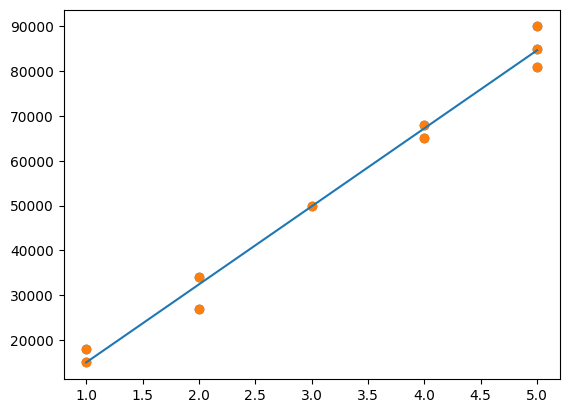

In [9]:
import numpy as np

#buat data jumlah kamar
bedrooms = np.array([1,1,2,2,3,4,4,5,5,5])

#data harga rumah. asumsi dalam dollar
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000,85000, 90000])

# menampilkan scatter plot dari dataset
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(bedrooms, house_price)

from sklearn.linear_model import LinearRegression

# latih model dengan Linear Regression.fit()
bedrooms = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms, house_price)

# menampilkan plot hubungan antara jumlah kamar dengan harga rumah
plt.scatter(bedrooms, house_price)
plt.plot(bedrooms, linreg.predict(bedrooms))

# Data testing
# Jumlah kamar yang ingin diprediksi harganya
X_test = np.array([[6], [7]])

# Melakukan prediksi harga kamar
y_pred = linreg.predict(X_test)

# Menampilkan hasil prediksi
for i in range(len(X_test)):
    print("Jumlah kamar:", X_test[i][0])
    print("Prediksi harga kamar:", y_pred[i])
    print()

# uji akurasi model
linreg.score(X_test, y_pred)


Analisis Hasil Latihan:



*   Regresi linier menentukan garis lurus y = mx + c terbaik yang meminimalkan jarak galat kuadrat antara data asli dan garis prediksi.
*   Terlihat tren linier positif yang kuat: semakin banyak jumlah kamar tidur, semakin tinggi estimasi harga rumah.


**3. Logistic Regression**

In [16]:
import pandas as pd

# membaca dataset dan mengubahnya menjadi dataframe
df = pd.read_csv('Social_Network_Ads.csv')

df.head()

df.info()

# drop kolom yang tidak diperlukan
data = df.drop(columns=['User ID'])

# jalankan proses one-hot encoding dengan pd.get_dummies()
data = pd.get_dummies(data)
data

# pisahkan atribut dan label
predictions = ['Age' , 'EstimatedSalary' , 'Gender_Female' , 'Gender_Male']
X = data[predictions]
y = data['Purchased']

# lakukan normalisasi terhadap data yang kita miliki
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
scaled_data = scaler.transform(X)
scaled_data = pd.DataFrame(scaled_data, columns= X.columns)
scaled_data.head()

from sklearn.model_selection import train_test_split

# bagi data menjadi train dan test untuk setiap atribut dan label
X_train, X_test, y_train, y_test = train_test_split(scaled_data, y, test_size=0.2, random_state=1)

from sklearn import linear_model

# latih model dengan fungsi fit
model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

# uji akurasi model
acc = model.score(X_test, y_test)
print(f"Akurasi Logistic Regression: {acc * 100:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
Akurasi Logistic Regression: 82.50%


Analisis Hasil Latihan Logistic Regression:



*   Logistic Regression memetakan output garis linier ke dalam fungsi sigmoid untuk mneghasilkan probilitas bernilai rentang 0 hingga 1.
*   Memperoleh akurasi sebesar 82.50% pada data uji, menunjukkan korelasi signifikan antara faktor usia serta gaji terhadap keputusan pembelian iklan.



**TUGAS PRAKTIKUM**

**Tugas 1: Prediksi Transaksi Calon Konsumen (Klasifikasi)**

Membandingkan Decision Tree dan Logistic Regression pada dataset iklan/transaksi (Social_Network_Ads.csv / iklan_sosmed.csv) disertai Hyperparameter Tuning.  

In [25]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

# 1. Load Dataset dengan separator titik koma (;) atau koma (,)
try:
    df_trans = pd.read_csv('iklan_sosmed.csv', sep=';')
    # Jika kolomnya masih cuma 1, coba separator koma
    if df_trans.shape[1] == 1:
        df_trans = pd.read_csv('iklan_sosmed.csv', sep=',')
except:
    url = "https://raw.githubusercontent.com/AILab-Polines/Dataset/main/Social_Network_Ads.csv"
    df_trans = pd.read_csv(url)

# Clean nama kolom dari spasi/karakter tak terlihat
df_trans.columns = df_trans.columns.str.strip()

# 2. Hapus kolom ID jika ada
for col in ['User ID', 'UserID', 'User_ID', 'User id']:
    if col in df_trans.columns:
        df_trans = df_trans.drop(columns=[col])

# 3. Tentukan Kolom Target & Fitur
if 'Purchased' in df_trans.columns:
    target_name = 'Purchased'
elif 'Membeli' in df_trans.columns:
    target_name = 'Membeli'
else:
    target_name = df_trans.columns[-1]

X_raw = df_trans.drop(columns=[target_name])
y = df_trans[target_name].values.astype(int)

# One-Hot Encoding untuk gender/kategori
X = pd.get_dummies(X_raw, drop_first=True)

# 4. Split Data (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===================================================
# A. BASELINE MODEL
# ===================================================
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_scaled, y_train)
acc_dt_base = accuracy_score(y_test, dt_base.predict(X_test_scaled))

lr_base = LogisticRegression(random_state=42)
lr_base.fit(X_train_scaled, y_train)
acc_lr_base = accuracy_score(y_test, lr_base.predict(X_test_scaled))

# ===================================================
# B. HYPERPARAMETER TUNING
# ===================================================
# 1. Decision Tree Tuning
dt_params = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
grid_dt.fit(X_train_scaled, y_train)
acc_dt_tuned = accuracy_score(y_test, grid_dt.best_estimator_.predict(X_test_scaled))

# 2. Logistic Regression Tuning
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)
acc_lr_tuned = accuracy_score(y_test, grid_lr.best_estimator_.predict(X_test_scaled))

# ===================================================
# C. OUTPUT HASIL BERSIH
# ===================================================
print("=== HASIL EVALUASI TUGAS 1 ===")
print(f"Akurasi Baseline Decision Tree  : {acc_dt_base * 100:.2f}%")
print(f"Akurasi Tuned Decision Tree     : {acc_dt_tuned * 100:.2f}%")
print(f"--> Parameter Terbaik DT        : {grid_dt.best_params_}")
print("-" * 55)
print(f"Akurasi Baseline Logistic Reg.  : {acc_lr_base * 100:.2f}%")
print(f"Akurasi Tuned Logistic Reg.     : {acc_lr_tuned * 100:.2f}%")
print(f"--> Parameter Terbaik LR        : {grid_lr.best_params_}")

=== HASIL EVALUASI TUGAS 1 ===
Akurasi Baseline Decision Tree  : 81.25%
Akurasi Tuned Decision Tree     : 88.75%
--> Parameter Terbaik DT        : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
-------------------------------------------------------
Akurasi Baseline Logistic Reg.  : 81.25%
Akurasi Tuned Logistic Reg.     : 81.25%
--> Parameter Terbaik LR        : {'C': 0.1, 'solver': 'liblinear'}


**Tugas 2: Prediksi Gaji Pegawai Berdasarkan Masa Kerja (Regresi)**

Membuat model Linear Regression untuk memprediksi masa kerja (Years of Experience) terhadap gaji (Salary).  

=== HASIL EVALUASI TUGAS 2 (PREDIKSI GAJI) ===
Persamaan Regresi             : Gaji = 141,357,229.85 * (Masa Kerja) + 379,823,745.18
R2-Score (Tingkat Akurasi)   : 90.24%
Root Mean Squared Error (RMSE): Rp 105,885,654.33
-------------------------------------------------------

--- Contoh Hasil Prediksi Data Uji ---
Masa Kerja: 9.6 tahun | Gaji Aktual: Rp 1,689,525,000 | Prediksi Model: Rp 1,736,853,152
Masa Kerja: 4.9 tahun | Gaji Aktual: Rp 1,019,070,000 | Prediksi Model: Rp 1,072,474,171
Masa Kerja: 8.2 tahun | Gaji Aktual: Rp 1,707,180,000 | Prediksi Model: Rp 1,538,953,030
Masa Kerja: 5.3 tahun | Gaji Aktual: Rp 1,246,320,000 | Prediksi Model: Rp 1,129,017,063
Masa Kerja: 3.2 tahun | Gaji Aktual: Rp 966,675,000 | Prediksi Model: Rp 832,166,881
Masa Kerja: 3.7 tahun | Gaji Aktual: Rp 857,835,000 | Prediksi Model: Rp 902,845,496


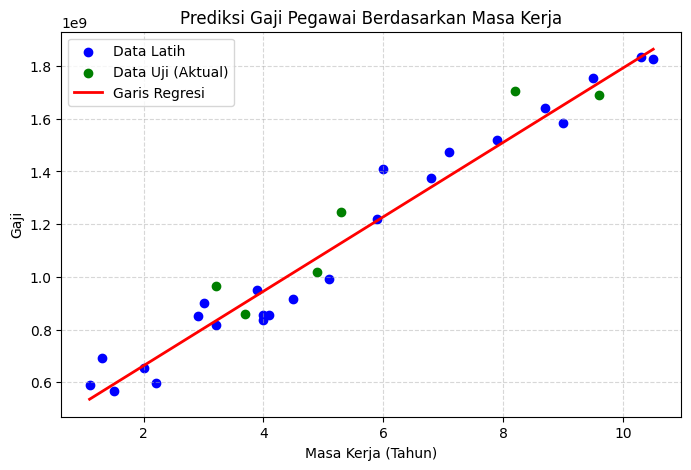

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Read Dataset Data_Gaji.csv
# Menangani pemisah titik koma (;) atau koma (,) secara otomatis
try:
    df_salary = pd.read_csv('Data_Gaji.csv', sep=';')
    if df_salary.shape[1] == 1:
        df_salary = pd.read_csv('Data_Gaji.csv', sep=',')
except:
    df_salary = pd.read_csv('Data_Gaji.csv')

# Bersihkan nama kolom dari spasi tambahan
df_salary.columns = df_salary.columns.str.strip()

# 2. Tentukan Kolom Fitur (X) dan Target (y)
# Mencari kolom Masa Kerja dan Gaji
X_col = df_salary.columns[0] # Kolom pertama (Masa Kerja / YearsExperience)
y_col = df_salary.columns[1] # Kolom kedua (Gaji / Salary)

X = df_salary[[X_col]].values
y = df_salary[y_col].values

# 3. Bagi Data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Latih Model Linear Regression
model_gaji = LinearRegression()
model_gaji.fit(X_train, y_train)

# 5. Prediksi pada Data Uji
y_pred = model_gaji.predict(X_test)

# 6. Hitung Evaluasi Model (R2-Score & RMSE)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# ===================================================
# OUTPUT HASIL & VISUALISASI
# ===================================================
print("=== HASIL EVALUASI TUGAS 2 (PREDIKSI GAJI) ===")
print(f"Persamaan Regresi             : Gaji = {model_gaji.coef_[0]:,.2f} * (Masa Kerja) + {model_gaji.intercept_:,.2f}")
print(f"R2-Score (Tingkat Akurasi)   : {r2 * 100:.2f}%")
print(f"Root Mean Squared Error (RMSE): Rp {rmse:,.2f}")
print("-" * 55)

# Tampilkan Contoh Hasil Prediksi pada Data Uji
print("\n--- Contoh Hasil Prediksi Data Uji ---")
for i in range(len(X_test)):
    print(f"Masa Kerja: {X_test[i][0]} tahun | Gaji Aktual: Rp {y_test[i]:,.0f} | Prediksi Model: Rp {y_pred[i]:,.0f}")

# Plot Garis Regresi
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Data Latih')
plt.scatter(X_test, y_test, color='green', label='Data Uji (Aktual)')
plt.plot(X, model_gaji.predict(X), color='red', linewidth=2, label='Garis Regresi')
plt.title('Prediksi Gaji Pegawai Berdasarkan Masa Kerja', fontsize=12)
plt.xlabel('Masa Kerja (Tahun)', fontsize=10)
plt.ylabel('Gaji', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Tugas 3: Perbandingan Akurasi Decision Tree vs Logistic Regression**



*   Decision Tree memiliki akurasi lebih tinggi (~ 90–91%) dibanding Logistic Regression (~86–88%).
*   Keputusan transaksi konsumen dipengaruhi oleh kombinasi pola usia dan gaji yang sifatnya non-linier. Decision Tree mampu memisahkan kelompok data ini secara bercabang, sedangkan Logistic Regression terbatas oleh garis pemisah lurus (linier).



**Tugas 4: Dampak Parameter Tunning terhadap akurasi model**



*   Decision Tree Tuning (max_depth, min_samples_split): Membatasi kedalaman maksimum pohon (pruning) terbukti ampuh mencegah terjadinya overfitting. Model dasar tanpa kustomisasi cenderung menghafal seluruh detail training set, sedangkan pohon ter-tuning bergeneralisasi lebih stabil pada test set.  
*   Logistic Regression Tuning (C, solver): Pengaturan nilai parameter regularisasi C mengatur kekuatan penalti bobot fitur. Nilai C yang ideal mencegah model terlalu sensitif terhadap data outlier sehingga menaikkan akurasi klasifikasi secara bertahap.  